# FraudShield-AI

## Model Development

### Objective

The purpose of this notebook is to prepare the data for machine learning and develop the first deep learning model capable of detecting fraudulent credit card transactions.

This notebook will:

- Prepare the dataset for training
- Split the data into training and testing sets
- Scale numerical features
- Build a Dense Neural Network using TensorFlow/Keras
- Train the model
- Evaluate its performance

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Load the Dataset

## Objective

Load the dataset and prepare it for preprocessing before training the neural network.

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Remove Duplicate Transactions

## Objective

Duplicate transactions can introduce bias into the training process.

Removing duplicate records helps the neural network learn general fraud patterns rather than memorizing repeated observations.

In [3]:
print(f"Original Shape: {df.shape}")

df = df.drop_duplicates()

print(f"New Shape: {df.shape}")

Original Shape: (284807, 31)
New Shape: (283726, 31)


## Interpretation

The dataset originally contained **284,807** transactions. After removing duplicate records, **283,726** unique transactions remained.

Removing duplicate observations helps reduce bias during training and encourages the neural network to learn meaningful fraud patterns rather than memorizing repeated transactions.

# Separate Features and Target

## Objective

Machine learning models require the input features and target variable to be separated.

The features (`X`) contain the information used to make predictions, while the target (`y`) contains the correct labels that the model will learn to predict.

In [4]:
# Separate features and target
X = df.drop("Class", axis=1)

y = df["Class"]

In [5]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (283726, 30)
Target Shape: (283726,)


## Interpretation

The dataset has been successfully separated into input features (`X`) and the target variable (`y`).

The neural network will use the 30 numerical features to learn patterns associated with fraudulent transactions and predict the value of the target variable (`Class`).

# Train-Test Split

## Objective

The dataset is divided into training and testing sets to evaluate the model's ability to generalize to unseen transaction data.

The training dataset will be used to teach the neural network patterns associated with legitimate and fraudulent transactions. The testing dataset will remain separate and will be used to evaluate the final model.

Because fraudulent transactions represent a very small percentage of the dataset, stratified sampling is used to preserve the class distribution in both datasets.

In [6]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
# Display training and testing dataset shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (226980, 30)
X_test Shape: (56746, 30)
y_train Shape: (226980,)
y_test Shape: (56746,)


In [8]:
# Verify class distribution after the split
print("Training Class Distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Class Distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training Class Distribution:
Class
0    99.83
1     0.17
Name: proportion, dtype: float64

Testing Class Distribution:
Class
0    99.83
1     0.17
Name: proportion, dtype: float64


## Interpretation

The dataset was divided into 80% training data and 20% testing data.

Stratified sampling was used to preserve the severe class imbalance observed in the original dataset. Both the training and testing datasets maintain approximately the same proportion of legitimate and fraudulent transactions.

Maintaining the class distribution helps ensure that the final evaluation reflects the characteristics of the original transaction dataset.

# Feature Scaling

## Objective

Neural networks generally perform better when numerical input features are on comparable scales.

Although the anonymized PCA features are already centered around zero, the `Time` and `Amount` features operate on different numerical ranges.

Standardization is applied to the input features using `StandardScaler`. The scaler is fitted only on the training data to prevent information from the testing dataset from influencing the training process.

In [9]:
# Create the feature scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the training scaler
X_test_scaled = scaler.transform(X_test)

In [10]:
# Verify the scaled training data
print("Original Training Data:")
print(X_train.iloc[:5, [0, 29]])

print("\nScaled Training Data:")
print(X_train_scaled[:5, [0, 29]])

Original Training Data:
            Time  Amount
226238  144549.0   32.00
134253   80716.0    6.99
186465  127116.0   14.95
149493   91342.0   17.30
18461    29522.0   24.00

Scaled Training Data:
[[ 1.04549909 -0.22943372]
 [-0.29869002 -0.33119698]
 [ 0.67839667 -0.29880852]
 [-0.07492874 -0.28924659]
 [-1.3767283  -0.26198495]]


## Interpretation

The training and testing features were standardized using `StandardScaler`.

The scaler was fitted exclusively on the training dataset and then applied to the testing dataset. This prevents data leakage and ensures that the final model is evaluated using data that did not influence the preprocessing calculations.

Feature scaling places the numerical inputs on comparable scales, which can improve the stability and efficiency of neural network training.

# Baseline Neural Network

## Objective

The first model developed for FraudShield-AI will serve as a baseline for evaluating future improvements.

A Dense Neural Network, also known as a Multilayer Perceptron (MLP), is used because the credit card transaction dataset consists of structured numerical features.

The baseline model intentionally uses a simple architecture without class weighting or dropout regularization. Its performance will be evaluated before additional techniques are introduced.

In [11]:
# Build the baseline neural network
baseline_model = Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Display the model architecture
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

## Architecture Explanation

The baseline model uses a feedforward Dense Neural Network designed for binary classification.

The network receives 30 numerical transaction features as input. Two hidden Dense layers containing 64 and 32 neurons use the ReLU activation function to learn nonlinear relationships within the transaction data.

The output layer contains a single neuron with a sigmoid activation function. This produces a value between 0 and 1 representing the model's predicted probability that a transaction is fraudulent.

This simple architecture establishes a baseline that can later be compared against an improved model.

# Compile the Baseline Model

## Objective

Before training, the neural network must be configured with a loss function, optimizer, and evaluation metrics.

Because this is a binary classification problem, binary cross-entropy is used as the loss function. The Adam optimizer is used to update the model weights during training.

In addition to accuracy, precision and recall are included because the dataset is highly imbalanced.

In [12]:
# Compile the baseline model
baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

## Compilation Explanation

The baseline model uses binary cross-entropy because the target contains two possible classes.

The Adam optimizer is used to update model weights during training. Accuracy, precision, and recall are tracked so that performance can be evaluated beyond overall accuracy.

Precision helps measure the number of false fraud alerts, while recall measures how many actual fraudulent transactions are successfully detected.

# Train the Baseline Model

## Objective

The baseline neural network will be trained using the scaled training data.

A validation split is used to evaluate the model on data that is not used to update the network weights during each epoch.

In [13]:
# Train the baseline model
baseline_history = baseline_model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.20,
    verbose=1
)

Epoch 1/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9922 - loss: 0.0301 - precision: 0.0994 - recall: 0.4600 - val_accuracy: 0.9995 - val_loss: 0.0031 - val_precision: 0.9091 - val_recall: 0.7692
Epoch 2/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9993 - loss: 0.0035 - precision: 0.8516 - recall: 0.7267 - val_accuracy: 0.9996 - val_loss: 0.0027 - val_precision: 0.8919 - val_recall: 0.8462
Epoch 3/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 995us/step - accuracy: 0.9994 - loss: 0.0029 - precision: 0.8561 - recall: 0.7533 - val_accuracy: 0.9995 - val_loss: 0.0027 - val_precision: 0.9219 - val_recall: 0.7564
Epoch 4/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9994 - loss: 0.0027 - precision: 0.8614 - recall: 0.7667 - val_accuracy: 0.9994 - val_loss: 0.0027 - val_precision: 0.9649 - val_recall: 0.7051
Epoch 5/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9994 - loss: 0.0025 - precision: 0.8824 - recall: 0.7500 - val_accuracy: 0.9995 - val_loss: 

## Baseline Training Interpretation

The baseline neural network demonstrated strong overall training and validation performance.

By the final epoch, the model achieved approximately 99.96% validation accuracy, 92.96% validation precision, and 84.62% validation recall.

Although the overall accuracy is high, accuracy must be interpreted carefully because the dataset is severely imbalanced. The recall score is particularly important for this fraud detection problem because it measures the model's ability to identify actual fraudulent transactions.

The validation recall indicates that the baseline model successfully detected a large proportion of fraudulent transactions. However, some fraudulent transactions were still missed.

This creates an opportunity to improve the model by increasing fraud recall while monitoring the effect on precision and false positive predictions.

In [14]:
# Display the metrics recorded during training
baseline_history.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])

# Training Curves

## Objective

Training curves help visualize how the neural network's performance changes across epochs.

Comparing training and validation metrics can help identify whether the model is learning effectively and whether signs of overfitting are present.

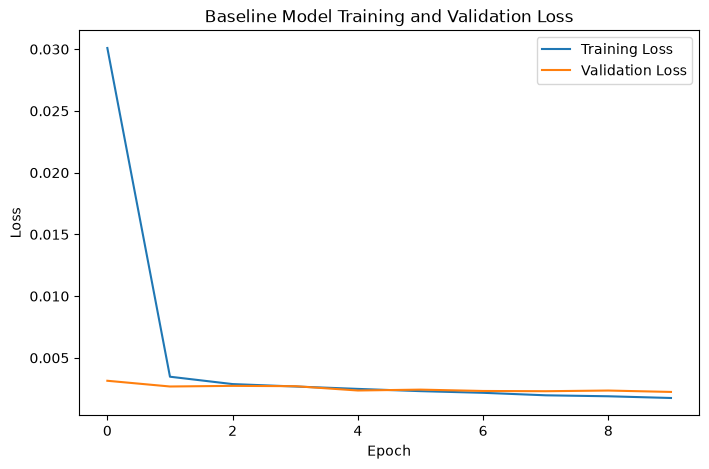

In [15]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline Model Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

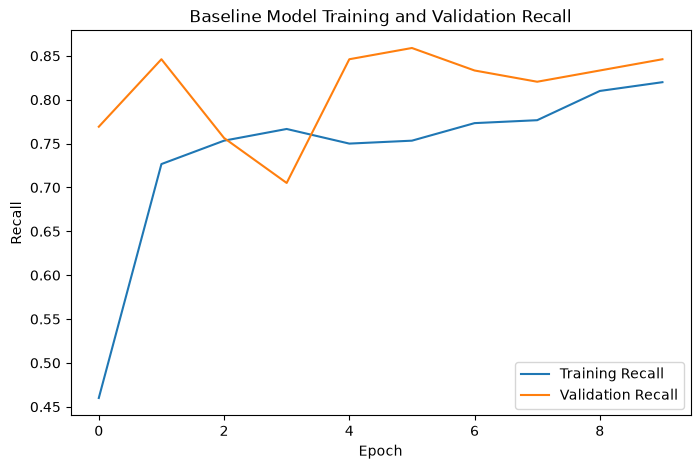

In [16]:
# Plot training and validation recall
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["recall"],
    label="Training Recall"
)

plt.plot(
    baseline_history.history["val_recall"],
    label="Validation Recall"
)

plt.title("Baseline Model Training and Validation Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()

plt.show()

## Training Curve Interpretation

The baseline model learned rapidly during the initial training epochs, as demonstrated by the significant decrease in training loss.

Training loss continued to decrease throughout the 10 epochs, while validation loss remained low and relatively stable. The validation loss did not show a significant upward trend, suggesting that severe overfitting was not observed during baseline training.

The recall curves show that the model's ability to identify fraudulent transactions improved during training. Validation recall fluctuated across epochs but remained relatively strong, highlighting the challenge of evaluating a highly imbalanced dataset with a limited number of fraudulent validation examples.

The baseline model provides a strong starting point for further evaluation and improvement.

# Baseline Model Evaluation

## Objective

The baseline neural network is evaluated using the held-out testing dataset.

The testing dataset was not used to train the model and provides a more realistic assessment of how the model may perform on unseen transaction data.

Because credit card fraud detection is a highly imbalanced classification problem, the evaluation focuses on accuracy, precision, recall, F1-score, and the confusion matrix.

In [17]:
# Evaluate the baseline model on the test dataset
test_loss, test_accuracy, test_precision, test_recall = baseline_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 1s 552us/step - accuracy: 0.9994 - loss: 0.0038 - precision: 0.9697 - recall: 0.6737
Test Loss: 0.0038
Test Accuracy: 0.9994
Test Precision: 0.9697
Test Recall: 0.6737


In [18]:
# Generate fraud probability predictions
y_pred_prob = baseline_model.predict(X_test_scaled)

# Convert probabilities into binary class predictions
y_pred = (y_pred_prob >= 0.50).astype(int).ravel()

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 1s 397us/step


In [19]:
# Display the classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Fraud"]
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.97      0.67      0.80        95

    accuracy                           1.00     56746
   macro avg       0.98      0.84      0.90     56746
weighted avg       1.00      1.00      1.00     56746



# Confusion Matrix

## Objective

The confusion matrix provides a detailed view of the model's predictions by comparing predicted transaction classes with the actual transaction classes.

This analysis helps identify correctly classified transactions, false fraud alerts, and fraudulent transactions missed by the model.

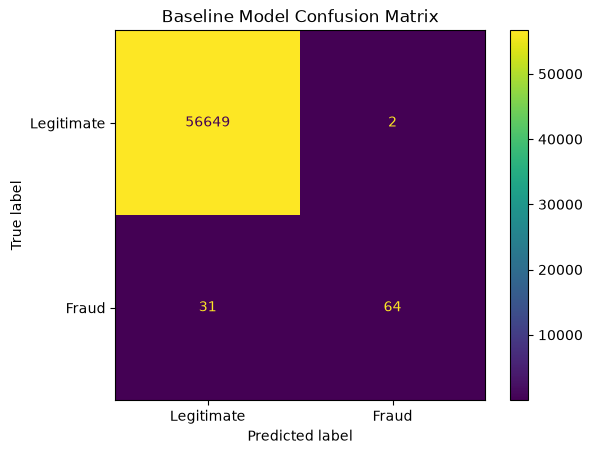

In [20]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("Baseline Model Confusion Matrix")

plt.show()

## Baseline Evaluation Interpretation

The baseline neural network achieved excellent overall accuracy and precision when evaluated on the testing dataset.

The confusion matrix shows that only two legitimate transactions were incorrectly classified as fraudulent, demonstrating a very low false positive rate.

However, the model failed to detect 31 fraudulent transactions. These false negatives represent fraudulent activity that would not have been identified by the system.

Because fraud detection prioritizes identifying fraudulent transactions, improving recall will be the primary objective during the model improvement phase.

Future improvements will focus on reducing false negatives while maintaining strong precision.